In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

In [14]:
!pip install ace_tools

In [2]:
# Example 1: Graph Neural Network (GNN) - Predict traffic volume at nodes

# Create a toy traffic graph
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)  # 3 nodes: 0 <-> 1 <-> 2

# Node features: e.g., current traffic volume at each node
x = torch.tensor([[10.0], [20.0], [30.0]], dtype=torch.float)

# Target: predict future traffic volume (just a toy example)
y = torch.tensor([[12.0], [18.0], [33.0]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index)

class GNNModel(nn.Module):
    def __init__(self):
        super(GNNModel, self).__init__()
        self.conv1 = GCNConv(1, 8)
        self.conv2 = GCNConv(8, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

gnn_model = GNNModel()
gnn_output = gnn_model(data)

In [3]:
# Example 2: Transformer - Predict traffic volume from time series
class SimpleTransformer(nn.Module):
    def __init__(self, seq_len=3, d_model=16):
        super(SimpleTransformer, self).__init__()
        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.out = nn.Linear(d_model, 1)

    def forward(self, x_seq):
        x = self.embedding(x_seq)
        x = self.transformer(x)
        x = self.out(x)
        return x

# Sequence input: past 3 time steps of traffic at one node
sequence = torch.tensor([[[10.0]], [[12.0]], [[15.0]]])  # [seq_len, batch, feature]
transformer_model = SimpleTransformer()
transformer_output = transformer_model(sequence)

/Users/lulu/anaconda3/envs/DeepLearning/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Show model outputs
gnn_df = pd.DataFrame({'Node': ['A', 'B', 'C'],
                       'Current Volume': x.squeeze().tolist(),
                       'Predicted Future Volume (GNN)': gnn_output.detach().squeeze().tolist(),
                       'True Future Volume': y.squeeze().tolist()})

transformer_pred = transformer_output.detach().squeeze().tolist()

gnn_df, transformer_pred

(  Node  Current Volume  Predicted Future Volume (GNN)  True Future Volume
 0    A            10.0                      -5.047475                12.0
 1    B            20.0                      -7.110091                18.0
 2    C            30.0                      -6.627694                33.0,
 [-0.15854999423027039, -0.32722213864326477, -0.25356101989746094])

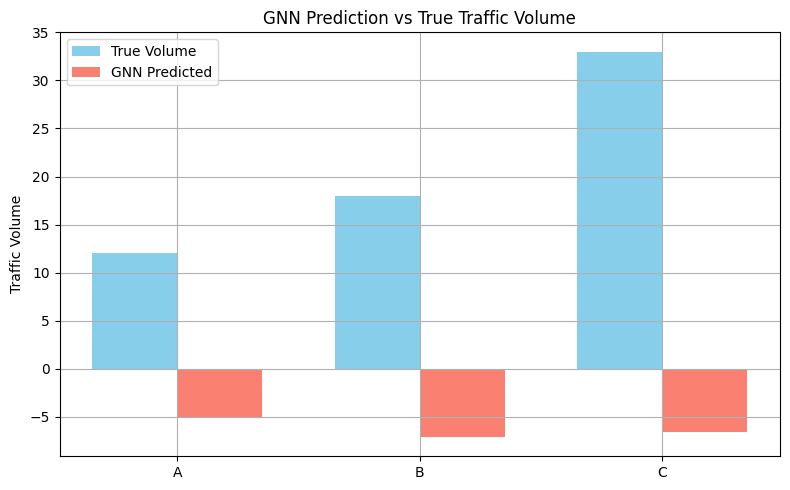

In [7]:
# Extract data
nodes = gnn_df['Node'].tolist()
true_vals = gnn_df['True Future Volume'].values
pred_vals = gnn_df['Predicted Future Volume (GNN)'].values

x = np.arange(len(nodes))  # [0, 1, 2]
width = 0.35

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, true_vals, width, label='True Volume', color='skyblue')
plt.bar(x + width/2, pred_vals, width, label='GNN Predicted', color='salmon')
plt.xticks(x, nodes)
plt.ylabel('Traffic Volume')
plt.title('GNN Prediction vs True Traffic Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


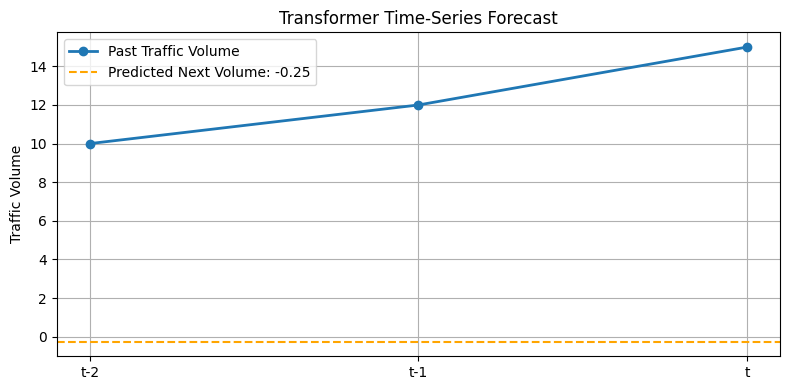

In [8]:
# Example past traffic volumes
past_traffic = [10, 12, 15]
future_pred = transformer_pred[-1]  # predicted next time step

# Time steps for plotting
time_steps = ['t-2', 't-1', 't']

plt.figure(figsize=(8, 4))
plt.plot(time_steps, past_traffic, marker='o', label='Past Traffic Volume', linewidth=2)
plt.axhline(y=future_pred, color='orange', linestyle='--', label=f'Predicted Next Volume: {future_pred:.2f}')
plt.ylabel('Traffic Volume')
plt.title('Transformer Time-Series Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
